## LOAD MODEL

In [ ]:
# Mount your google drive where you've saved your assignment folder
from google.colab import drive
drive.mount('/content/drive', force_remount=True)



Mounted at /content/drive


## Install packages

In [ ]:
!pip install transformers torch torchvision

In [ ]:
 import transformers
 import torch
 import torchvision
 print(transformers.__version__)
 print(torch.__version__)
 print(torchvision.__version__)
 ! python --version

5.0.0
2.10.0+cpu
0.25.0+cpu
Python 3.12.13


In [ ]:
import os
import pandas as pd


from transformers import (
    OneFormerProcessor,
    OneFormerForUniversalSegmentation,
    OneFormerConfig
)
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import torch
from pathlib import Path

## remap labels

In [ ]:

# ── Build the remap lookup table from uhumans2_office.yaml ───────────────────
# sub_id = raw simulator label, super_id = uHumans2 office label
REMAP = {
    10: 1,   # air_vent
    5:  2,   # books
    14: 3,   # floor
    202: 0,  # unknown
    128: 4,  # ceiling_light
    191: 19, # wall
    100: 9,  # cabinet
    28: 5,   # chair
    36: 7,   # couch
    163: 16, # desk
    151: 10, # computer
    71: 3,   # floor
    86: 11,  # lamp
    93: 6,   # bench
    198: 12, # painting
    130: 13, # plant
    131: 14, # sign
    148: 20, # human
    161: 17, # cubicle
    193: 18, # trashcan
    203: 15, # stairs
    204: 0,  # unknown
}
NUM_CLASSES = 21  # uHumans2 office labelspace

# Build a fast numpy lookup array (index = raw ID, value = remapped ID)
# Any raw ID not in the remap table gets mapped to 0 (unknown)
REMAP_LUT = np.zeros(256, dtype=np.uint8)
for raw_id, remapped_id in REMAP.items():
    if raw_id < 256:
        REMAP_LUT[raw_id] = remapped_id

def apply_remap(seg_array: np.ndarray) -> np.ndarray:
    """Convert raw simulator label IDs to uHumans2 office label IDs."""
    # Clip to 255 to stay within LUT bounds
    clipped = np.clip(seg_array, 0, 255).astype(np.uint8)
    return REMAP_LUT[clipped]



In [ ]:
# ── Verify remap on one sample ────────────────────────────────────────────────
drive_path = "/content/drive/MyDrive/SBU/Advanced_Project_Robotics/dataset"
model_dir = "/content/drive/MyDrive/SBU/Advanced_Project_Robotics/Semantics/models/oneformer_ade20k_swin_large/trained_on_uhumans/"
sample_seg = next(Path(f"{drive_path}/tesse_seg_cam_converted_image_raw").glob("*.jpg"))
raw = np.array(Image.open(sample_seg))
remapped = apply_remap(raw)

print(f"Raw labels:      {sorted(np.unique(raw).tolist())}")
print(f"Remapped labels: {sorted(np.unique(remapped).tolist())}")
print(f"All remapped IDs within 0-20: {remapped.max() <= 20}")


Raw labels:      [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 95, 96, 97, 98, 99, 100, 101, 102, 103, 105, 106, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210]
Remapped labels: [0, 1, 2, 3, 4, 5, 7, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20]
All remapped IDs within 0-20: True


## load model

In [ ]:

# ── Load model config to get correct num_text ─────────────────────────────────
model_config = OneFormerConfig.from_pretrained("shi-labs/oneformer_ade20k_swin_large")
# print(f"\nnum_text from config: {model_config.num_text}")
# print(f"task_seq_len: {model_config.task_seq_len}")
model_config.num_queries= 250
model_config.text_encoder_n_ctx = 16
model_config.num_text = model_config.num_queries - model_config.text_encoder_n_ctx
# Patch processor with correct values
processor = OneFormerProcessor.from_pretrained("shi-labs/oneformer_ade20k_swin_large")
processor.image_processor.num_text = model_config.num_text
processor.image_processor.task_seq_len = 77

# ── Reinitialize model head for 21 classes ────────────────────────────────────
# The pretrained model has 150-class output — we replace the head for 21 classes
# but keep all the backbone weights (transfer learning)
model_config.num_labels = NUM_CLASSES
model_config.is_training=True

# Build class metadata for the 21 uHumans2 labels
UHUMANS2_CLASSES = [
    "unknown", "air_vent", "books", "floor", "ceiling_light",
    "chair", "bench", "couch", "stairs", "cabinet",
    "computer", "lamp", "painting", "plant", "sign",
    "stairs", "desk", "cubicle", "trashcan", "wall", "human"
]
model_config.id2label = {i: name for i, name in enumerate(UHUMANS2_CLASSES)}
model_config.label2id = {name: i for i, name in enumerate(UHUMANS2_CLASSES)}

# Load pretrained weights then replace the classification head
model = OneFormerForUniversalSegmentation.from_pretrained(
    "shi-labs/oneformer_ade20k_swin_large",
    config=model_config,
    ignore_mismatched_sizes=True
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
The image processor of type `OneFormerImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/826 [00:00<?, ?it/s]

OneFormerForUniversalSegmentation LOAD REPORT from: shi-labs/oneformer_ade20k_swin_large
Key                                                                                            | Status   |                                                                                        
-----------------------------------------------------------------------------------------------+----------+----------------------------------------------------------------------------------------
model.text_mapper.text_encoder.transformer.layers.{0, 1, 2, 3, 4, 5}.layer_norm1.weight        | MISSING  |                                                                                        
model.text_mapper.text_encoder.transformer.layers.{0, 1, 2, 3, 4, 5}.mlp.fc2.weight            | MISSING  |                                                                                        
model.text_mapper.text_encoder.transformer.layers.{0, 1, 2, 3, 4, 5}.mlp.fc1.bias              | MISSING  |                    

In [ ]:
model_config2 = OneFormerConfig.from_pretrained("shi-labs/oneformer_ade20k_swin_large")
print(type(model_config2))
print(dir(model_config2))
print(model_config2.text_encoder_n_ctx)
print(model_config2.num_queries)

<class 'transformers.models.oneformer.configuration_oneformer.OneFormerConfig'>
['__annotations__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slotnames__', '__str__', '__subclasshook__', '__weakref__', '_attn_implementation', '_attn_implementation_internal', '_auto_class', '_check_received_keys', '_commit_hash', '_create_id_label_maps', '_decode_special_floats', '_dict_from_json_file', '_encode_special_floats', '_experts_implementation', '_experts_implementation_internal', '_get_config_dict', '_get_files_timestamps', '_get_generation_parameters', '_name_or_path', '_output_attentions', '_remove_keys_not_serialized', '_upload_modified_files', '_validate_default_rope_parameters', '_validate_dynamic_rope_par

In [ ]:
critical_fields = ["num_text", "task_seq_len", "num_labels",
                   "image_mean", "image_std"]
for field in critical_fields:
    val = getattr(processor.image_processor, field, "MISSING")
    status = "✓" if val is not None and val != "MISSING" else "✗"
    print(f"  {status} {field}: {val}")

  ✓ num_text: 234
  ✓ task_seq_len: 77
  ✓ num_labels: 150
  ✓ image_mean: [0.48500001430511475, 0.4560000002384186, 0.4059999883174896]
  ✓ image_std: [0.2290000021457672, 0.2239999920129776, 0.22499999403953552]


In [ ]:
# model.model.text_mapper.text_embeddings.weight.shape
print(type(model))
print(type(model.model))
print(type(model.model.text_mapper))
print(dir(model.model.text_mapper))
model.model.text_mapper.text_embeddings.weight.shape

<class 'transformers.models.oneformer.modeling_oneformer.OneFormerForUniversalSegmentation'>
<class 'transformers.models.oneformer.modeling_oneformer.OneFormerModel'>
<class 'transformers.models.oneformer.modeling_oneformer.OneFormerTextMapper'>
['T_destination', '__annotations__', '__call__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_apply', '_backward_hooks', '_backward_pre_hooks', '_buffers', '_call_impl', '_compiled_call_impl', '_forward_hooks', '_forward_hooks_always_called', '_forward_hooks_with_kwargs', '_forward_pre_hooks', '_forward_pre_hooks_with_kwargs', '_get_backward_hooks', '_get_backward_pre_hooks', '_get_name', '_is_full_back

AttributeError: 'OneFormerTextMapper' object has no attribute 'text_embeddings'

## data loader

In [ ]:

# ── Dataset ───────────────────────────────────────────────────────────────────
class UHumans2Dataset(Dataset):
    def __init__(self, rgb_dir, seg_dir, processor):
        self.rgb_files = sorted(Path(rgb_dir).glob("*.jpg"))
        self.seg_dir = Path(seg_dir)
        self.processor = processor

        # Check for missing pairs
        missing = [f.name for f in self.rgb_files if not self._find_seg(f)]
        if missing:
            print(f"⚠️  {len(missing)} files missing seg pair. First 3: {missing[:3]}")
        print(f"Dataset: {len(self.rgb_files)} samples")

    def _find_seg(self, rgb_path):
        for ext in [".jpg", ".png"]:
            p = self.seg_dir / (rgb_path.stem + ext)
            if p.exists():
                return p
        return None

    def __len__(self):
        return len(self.rgb_files)

    def __getitem__(self, idx):
        rgb_path = self.rgb_files[idx]
        seg_path = self._find_seg(rgb_path)
        if seg_path is None:
            raise FileNotFoundError(f"No seg for {rgb_path.name}")

        image = Image.open(rgb_path).convert("RGB")

        # Load and remap labels
        raw_seg = np.array(Image.open(seg_path))
        if raw_seg.ndim == 3:
            raw_seg = raw_seg[:, :, 0]
        remapped_seg = apply_remap(raw_seg)
        seg = Image.fromarray(remapped_seg)

        inputs = self.processor(
            images=image,
            segmentation_maps=seg,
            task_inputs=["semantic"],
            return_tensors="pt"
        )

        return {
                k: (v.squeeze(0) if isinstance(v, torch.Tensor) else v)
                for k, v in inputs.items()
            }




## training

In [ ]:
# ── Training ──────────────────────────────────────────────────────────────────
dataset = UHumans2Dataset(
    rgb_dir=f"{drive_path}/tesse_left_cam_rgb_image_raw",
    seg_dir=f"{drive_path}/tesse_seg_cam_converted_image_raw",
    processor=processor
)

# Test one sample before training
print("\nTesting single sample...")
sample = dataset[0]
print("Keys:", list(sample.keys()))
print("pixel_values shape:", sample["pixel_values"].shape)
print("Single sample OK ✓")

loader = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nTraining on: {device}")
model = model.to(device)

# Use a lower LR for backbone, higher for the new head
backbone_params, head_params = [], []

for name, param in model.named_parameters():
    if "backbone" in name:
        backbone_params.append(param)
    else:
        head_params.append(param)

optimizer = torch.optim.AdamW(
    [
        {"params": backbone_params, "lr": 1e-5},
        {"params": head_params, "lr": 1e-4},
    ]
)


scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=5 * len(loader)
)

best_loss = float("inf")
model.train()

for epoch in range(5):
    epoch_loss = 0.0
    for i, batch in enumerate(loader):
        batch = {
            k: v.to(device) if isinstance(v, torch.Tensor) else v
            for k, v in batch.items()
        }
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        epoch_loss += loss.item()
        if i % 20 == 0:
            print(f"  Epoch {epoch+1} [{i}/{len(loader)}] loss: {loss.item():.4f}")

    avg = epoch_loss / len(loader)
    print(f"Epoch {epoch+1} avg loss: {avg:.4f}")

    if avg < best_loss:
        best_loss = avg
        model.save_pretrained(model_dir+"/oneformer_uhumans2_best")
        processor.save_pretrained(model_dir+"/oneformer_uhumans2_best")
        print(f"  ✓ Saved best model (loss={avg:.4f})")

model.save_pretrained(model_dir)
processor.save_pretrained(model_dir)
print("Training complete.")

NameError: name 'UHumans2Dataset' is not defined

## DEBUGGING

In [ ]:
#

# Mount your google drive where you've saved your assignment folder
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

!pip install transformers torch torchvision

import os
import pandas as pd


from transformers import (
    OneFormerProcessor,
    OneFormerForUniversalSegmentation,
    OneFormerConfig
)
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import torch
from pathlib import Path

Mounted at /content/drive


In [ ]:



# ── Build the remap lookup table from uhumans2_office.yaml ───────────────────
# sub_id = raw simulator label, super_id = uHumans2 office label
REMAP = {
    10: 1,   # air_vent
    5:  2,   # books
    14: 3,   # floor
    202: 0,  # unknown
    128: 4,  # ceiling_light
    191: 19, # wall
    100: 9,  # cabinet
    28: 5,   # chair
    36: 7,   # couch
    163: 16, # desk
    151: 10, # computer
    71: 3,   # floor
    86: 11,  # lamp
    93: 6,   # bench
    198: 12, # painting
    130: 13, # plant
    131: 14, # sign
    148: 20, # human
    161: 17, # cubicle
    193: 18, # trashcan
    203: 15, # stairs
    204: 0,  # unknown
}
NUM_CLASSES = 21  # uHumans2 office labelspace

REMAP_LUT = np.zeros(256, dtype=np.uint8)
for raw_id, remapped_id in REMAP.items():
    if raw_id < 256:
        REMAP_LUT[raw_id] = remapped_id

def apply_remap(seg_array: np.ndarray) -> np.ndarray:
    """Convert raw simulator label IDs to uHumans2 office label IDs."""
    clipped = np.clip(seg_array, 0, 255).astype(np.uint8)
    return REMAP_LUT[clipped]

# ── Verify remap on one sample ────────────────────────────────────────────────
drive_path = "/content/drive/MyDrive/SBU/Advanced_Project_Robotics/dataset"
model_dir = "/content/drive/MyDrive/SBU/Advanced_Project_Robotics/Semantics/models/oneformer_ade20k_swin_large/trained_on_uhumans/"
sample_seg = next(Path(f"{drive_path}/tesse_seg_cam_converted_image_raw").glob("*.jpg"))
raw = np.array(Image.open(sample_seg))
remapped = apply_remap(raw)

print(f"Raw labels:      {sorted(np.unique(raw).tolist())}")
print(f"Remapped labels: {sorted(np.unique(remapped).tolist())}")
print(f"All remapped IDs within 0-20: {remapped.max() <= 20}")

Raw labels:      [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 95, 96, 97, 98, 99, 100, 101, 102, 103, 105, 106, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210]
Remapped labels: [0, 1, 2, 3, 4, 5, 7, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20]
All remapped IDs within 0-20: True


In [ ]:
# ── Load model config ─────────────────────────────────
model_config = OneFormerConfig.from_pretrained("shi-labs/oneformer_ade20k_swin_large")
model_config.num_queries= 250
model_config.text_encoder_n_ctx = 16
model_config.num_text = model_config.num_queries - model_config.text_encoder_n_ctx
processor = OneFormerProcessor.from_pretrained("shi-labs/oneformer_ade20k_swin_large")
processor.image_processor.num_text = model_config.num_text
processor.task_seq_length = 77

# ── Reinitialize model head for 21 classes ────────────────────────────────────
model_config.num_labels = NUM_CLASSES
model_config.is_training=True

# Build class metadata for the 21 uHumans2 labels
UHUMANS2_CLASSES = [
    "unknown", "air_vent", "books", "floor", "ceiling_light",
    "chair", "bench", "couch", "stairs", "cabinet",
    "computer", "lamp", "painting", "plant", "sign",
    "stairs", "desk", "cubicle", "trashcan", "wall", "human"
]
model_config.id2label = {i: name for i, name in enumerate(UHUMANS2_CLASSES)}
model_config.label2id = {name: i for i, name in enumerate(UHUMANS2_CLASSES)}

# Load pretrained weights then replace the classification head
model = OneFormerForUniversalSegmentation.from_pretrained(
    "shi-labs/oneformer_ade20k_swin_large",
    config=model_config,
    ignore_mismatched_sizes=True
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
The image processor of type `OneFormerImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/826 [00:00<?, ?it/s]

OneFormerForUniversalSegmentation LOAD REPORT from: shi-labs/oneformer_ade20k_swin_large
Key                                                                                            | Status   |                                                                                        
-----------------------------------------------------------------------------------------------+----------+----------------------------------------------------------------------------------------
model.text_mapper.text_encoder.transformer.layers.{0, 1, 2, 3, 4, 5}.self_attn.in_proj_weight  | MISSING  |                                                                                        
model.text_mapper.text_encoder.transformer.layers.{0, 1, 2, 3, 4, 5}.layer_norm2.bias          | MISSING  |                                                                                        
model.text_mapper.text_encoder.transformer.layers.{0, 1, 2, 3, 4, 5}.self_attn.in_proj_bias    | MISSING  |                    

In [ ]:

# ── Dataset ───────────────────────────────────────────────────────────────────
class UHumans2Dataset(Dataset):
    def __init__(self, rgb_dir, seg_dir, processor):
        self.rgb_files = sorted(Path(rgb_dir).glob("*.jpg"))
        self.seg_dir = Path(seg_dir)
        self.processor = processor

        # Check for missing pairs
        missing = [f.name for f in self.rgb_files if not self._find_seg(f)]
        if missing:
            print(f"⚠️  {len(missing)} files missing seg pair. First 3: {missing[:3]}")
        print(f"Dataset: {len(self.rgb_files)} samples")

    def _find_seg(self, rgb_path):
        for ext in [".jpg", ".png"]:
            p = self.seg_dir / (rgb_path.stem + ext)
            if p.exists():
                return p
        return None

    def __len__(self):
        return len(self.rgb_files)

    def __getitem__(self, idx):
        rgb_path = self.rgb_files[idx]
        seg_path = self._find_seg(rgb_path)
        if seg_path is None:
            raise FileNotFoundError(f"No seg for {rgb_path.name}")

        image = Image.open(rgb_path).convert("RGB")

        # Load and remap labels
        raw_seg = np.array(Image.open(seg_path))
        if raw_seg.ndim == 3:
            raw_seg = raw_seg[:, :, 0]
        remapped_seg = apply_remap(raw_seg)
        seg = Image.fromarray(remapped_seg)

        inputs = self.processor(
            images=image,
            segmentation_maps=seg,
            task_inputs=["panoptic"],
            return_tensors="pt"
        )

        processed_inputs = {}
        for k, v in inputs.items():
            if isinstance(v, list) and len(v) > 0 and isinstance(v[0], torch.Tensor):
                processed_inputs[k] = v[0]
            elif isinstance(v, torch.Tensor):
                processed_inputs[k] = v.squeeze(0)
            else:
                processed_inputs[k] = v

        return processed_inputs

def collate_fn(batch):
    collated = {}
    for key in batch[0].keys():
        if key in ["pixel_values", "pixel_mask", "text_inputs", "task_inputs"]:
            collated[key] = torch.stack([b[key] for b in batch])
        else:
            # mask_labels and class_labels stay as lists — variable targets per image
            collated[key] = [b[key] for b in batch]
    return collated

In [ ]:
# ── Training ──────────────────────────────────────────────────────────────────
dataset = UHumans2Dataset(
    rgb_dir=f"{drive_path}/tesse_left_cam_rgb_image_raw",
    seg_dir=f"{drive_path}/tesse_seg_cam_converted_image_raw",
    processor=processor
)

# Test one sample before training
print("\nTesting single sample...")
sample = dataset[0]
print("Keys:", list(sample.keys()))
print("pixel_values shape:", sample["pixel_values"].shape)
print("Single sample OK ✓")

loader = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=2, collate_fn=collate_fn)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nTraining on: {device}")
model = model.to(device)

# Use a lower LR for backbone, higher for the new head
backbone_params, head_params = [], []

for name, param in model.named_parameters():
    if "backbone" in name:
        backbone_params.append(param)
    else:
        head_params.append(param)

optimizer = torch.optim.AdamW(
    [
        {"params": backbone_params, "lr": 1e-5},
        {"params": head_params, "lr": 1e-4},
    ]
)


scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=5 * len(loader)
)

best_loss = float("inf")
model.train()


for i, batch in enumerate(loader):
    batch_on_device = {}
    for k, v in batch.items():
        if isinstance(v, torch.Tensor):
            batch_on_device[k] = v.to(device)
        elif isinstance(v, list):
            batch_on_device[k] = [
                item.to(device) if isinstance(item, torch.Tensor) else item
                for item in v
            ]
        else:
            batch_on_device[k] = v

    for i, j in batch_on_device.items():
      try:
        print(f"{i}: {j.shape}")
      except:
        print(f"{i}: {type(j[0])}")
    break
    '''
    outputs = model(**batch_on_device)

    print(f"\ntype: {type(outputs)}")
    print(f"\nlen: {len(outputs)}")
    '''

Dataset: 8307 samples

Testing single sample...
Keys: ['pixel_values', 'pixel_mask', 'mask_labels', 'class_labels', 'text_inputs', 'task_inputs']
pixel_values shape: torch.Size([3, 640, 960])
Single sample OK ✓

Training on: cpu
pixel_values: torch.Size([1, 3, 640, 960])
pixel_mask: torch.Size([1, 640, 960])
mask_labels: <class 'torch.Tensor'>
class_labels: <class 'torch.Tensor'>
text_inputs: torch.Size([1, 234, 77])
task_inputs: torch.Size([1, 77])


# Validation

In [17]:
from transformers import OneFormerProcessor, OneFormerForUniversalSegmentation

model_path = "/content/model/"
processor = OneFormerProcessor.from_pretrained(model_path)
model = OneFormerForUniversalSegmentation.from_pretrained(model_path)
model.eval()

Loading weights:   0%|          | 0/907 [00:00<?, ?it/s]

OneFormerForUniversalSegmentation(
  (model): OneFormerModel(
    (pixel_level_module): OneFormerPixelLevelModule(
      (encoder): SwinBackbone(
        (embeddings): SwinEmbeddings(
          (patch_embeddings): SwinPatchEmbeddings(
            (projection): Conv2d(3, 192, kernel_size=(4, 4), stride=(4, 4))
          )
          (norm): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
        )
        (encoder): SwinEncoder(
          (layers): ModuleList(
            (0): SwinStage(
              (blocks): ModuleList(
                (0): SwinLayer(
                  (layernorm_before): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
                  (attention): SwinAttention(
                    (self): SwinSelfAttention(
                      (query): Linear(in_features=192, out_features=192, bias=True)
                      (key): Linear(in_features=192, out_features=192, bias=True)
                      (value): Li

In [18]:
model.model.is_training = False
print(f"Model's internal is_training flag set to: {model.model.is_training}")

Model's internal is_training flag set to: False


In [19]:
import torch
from tqdm import tqdm
from pathlib import Path
from PIL import Image
import numpy as np

def segment_image(image_path: Path) -> np.ndarray:
    image = Image.open(image_path).convert("RGB")
    # OneFormer needs a task input
    inputs = processor(images=image, task_inputs=["panoptic"], return_tensors="pt")

    processed_inputs = {}
    for k, v in inputs.items():
        if isinstance(v, list) and len(v) > 0 and isinstance(v[0], torch.Tensor):
            processed_inputs[k] = v[0]
        elif isinstance(v, torch.Tensor):
            processed_inputs[k] = v.squeeze(0)
        else:
            processed_inputs[k] = v

    with torch.no_grad():
        outputs = model(**inputs)
    seg = processor.post_process_semantic_segmentation(
        outputs, target_sizes=[image.size[::-1]]
    )[0]
    return seg.numpy().astype(np.uint8)

Original image: 


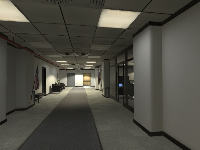

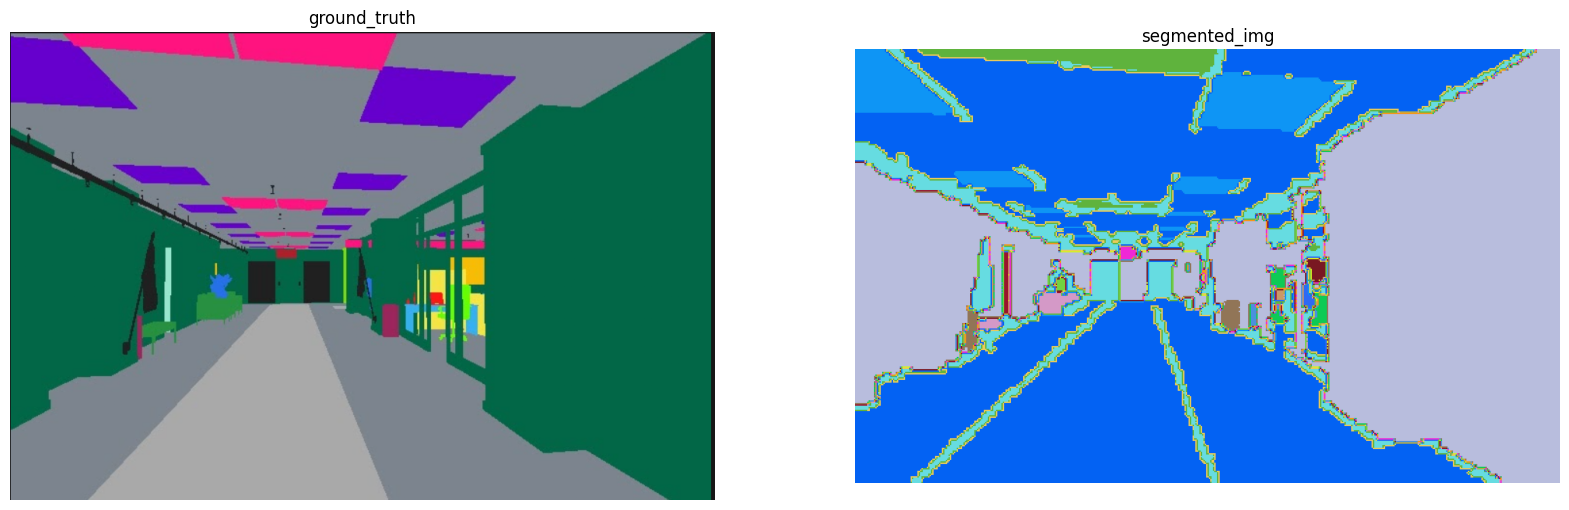

In [20]:
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2


segmented_img = segment_image("sample_rgb_image.png")

np.random.seed(42)
PALETTE = np.random.randint(0, 255, (256, 3), dtype=np.uint8)

def colorize_mask(mask):
  mask = cv2.resize(mask, (520, 320))
  return PALETTE[mask]

img = cv2.imread("sample_rgb_image.png")

print("Original image: ")
cv2_imshow(img)

# Load images
img1 = mpimg.imread('expected_ground_truth.png')

# Create a figure with 1 row and 2 columns
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

ax[0].imshow(img1)
ax[0].axis('off')  # Hide axes for a cleaner look
ax[0].set_title('ground_truth')

ax[1].imshow(colorize_mask(segmented_img))
ax[1].axis('off')
ax[1].set_title('segmented_img')

plt.show()